In [6]:
import sys
!{sys.executable} -m pip install statsmodels

You should consider upgrading via the '/Users/minah/Desktop/포트폴리오/semiconductor-yield-prediction/.venv/bin/python -m pip install --upgrade pip' command.


In [7]:
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

In [8]:
#연습용 식각 데이터 생성

np.random.seed(42)

df = pd.DataFrame({
    'CHAMBER_ID': (
        ['CHAMBER_A'] * 30 +
        ['CHAMBER_B'] * 30 +
        ['CHAMBER_C'] * 30
    ),
    
    'RECIPE_ID': ['RECIPE_001'] * 90,
    
    'ETCH_RATE': np.concatenate([
        np.random.normal(100, 3, 30),
        np.random.normal(105, 3, 30),
        np.random.normal(101, 3, 30)
    ])
})

df.head()

,CHAMBER_ID,RECIPE_ID,ETCH_RATE
0,CHAMBER_A,RECIPE_001,101.490142
1,CHAMBER_A,RECIPE_001,99.585207
2,CHAMBER_A,RECIPE_001,101.943066
3,CHAMBER_A,RECIPE_001,104.569090
4,CHAMBER_A,RECIPE_001,99.297540


In [9]:
#챔버마다 Etch Rate의 평균, 표준편차 등을 확인

print(df.shape)
print(df['CHAMBER_ID'].value_counts())

df.groupby('CHAMBER_ID')['ETCH_RATE'].describe()

(90, 3)
CHAMBER_ID
CHAMBER_A    30
CHAMBER_B    30
CHAMBER_C    30
Name: count, dtype: int64


,count,mean,std,min,25%,50%,75%,max
CHAMBER_ID,,,,,,,,
CHAMBER_A,30.0,99.435559,2.700019,94.260159,98.226847,99.297565,101.081006,104.737638
CHAMBER_B,30.0,104.636513,2.793307,99.120990,102.872659,104.806282,106.633985,110.556835
CHAMBER_C,30.0,101.038654,2.975949,93.140765,99.457574,101.076832,103.213134,105.693931


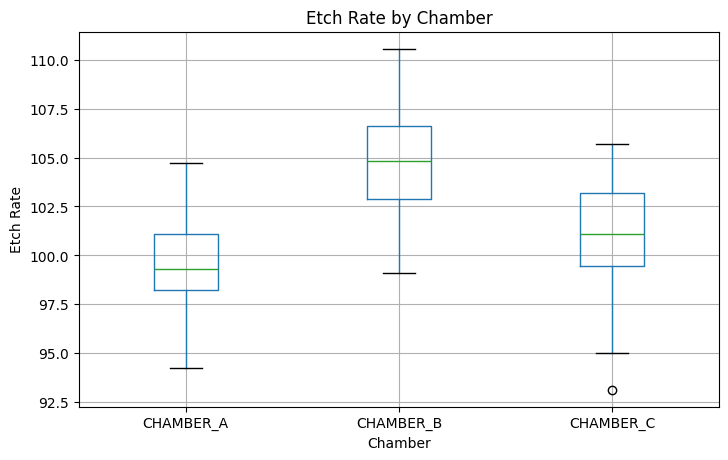

In [10]:
df.boxplot(
    column='ETCH_RATE',
    by='CHAMBER_ID',
    figsize=(8, 5)
)

plt.title('Etch Rate by Chamber')
plt.suptitle('')
plt.xlabel('Chamber')
plt.ylabel('Etch Rate')
plt.show()

#식각률 분포 확인

In [11]:
df_filtered = df[df['RECIPE_ID'] == 'RECIPE_001'].copy()

df_filtered.head()

,CHAMBER_ID,RECIPE_ID,ETCH_RATE
0,CHAMBER_A,RECIPE_001,101.490142
1,CHAMBER_A,RECIPE_001,99.585207
2,CHAMBER_A,RECIPE_001,101.943066
3,CHAMBER_A,RECIPE_001,104.569090
4,CHAMBER_A,RECIPE_001,99.297540


In [12]:
#챔버별 데이터 그룹 만들기

groups = [
    group['ETCH_RATE'].values
    for _, group in df_filtered.groupby('CHAMBER_ID')
]

print("챔버 수:", len(groups))

챔버 수: 3


In [13]:
#p-value < 0.05
#→ 챔버 사이에 Etch Rate 평균 차이가 있다고 판단

#p-value >= 0.05
#→ 챔버 사이에 통계적으로 뚜렷한 차이를 확인하지 못함

f_stat, p_value = stats.f_oneway(*groups)

print(f"F-statistic: {f_stat:.4f}")
print(f"p-value: {p_value:.6f}")

F-statistic: 26.6595
p-value: 0.000000


In [14]:
if p_value < 0.05:
    print("챔버 간 Etch Rate에 통계적으로 유의한 차이가 있습니다.")
else:
    print("챔버 간 Etch Rate에 통계적으로 유의한 차이가 없습니다.")

챔버 간 Etch Rate에 통계적으로 유의한 차이가 있습니다.


In [15]:
#True  → 두 챔버 간 평균 차이가 유의함
#False → 유의한 차이를 확인하지 못함

if p_value < 0.05:
    
    tukey = pairwise_tukeyhsd(
        endog=df_filtered['ETCH_RATE'],
        groups=df_filtered['CHAMBER_ID'],
        alpha=0.05
    )
    
    print(tukey.summary())

   Multiple Comparison of Means - Tukey HSD, FWER=0.05    
  group1    group2  meandiff p-adj   lower   upper  reject
----------------------------------------------------------
CHAMBER_A CHAMBER_B    5.201    0.0  3.4614  6.9405   True
CHAMBER_A CHAMBER_C   1.6031 0.0772 -0.1364  3.3426  False
CHAMBER_B CHAMBER_C  -3.5979    0.0 -5.3374 -1.8583   True
----------------------------------------------------------


In [16]:
#챔버별 평균 Etch Rate 확인

chamber_mean = (
    df_filtered
    .groupby('CHAMBER_ID')['ETCH_RATE']
    .mean()
    .sort_values()
)

print(chamber_mean)

CHAMBER_ID
CHAMBER_A     99.435559
CHAMBER_C    101.038654
CHAMBER_B    104.636513
Name: ETCH_RATE, dtype: float64


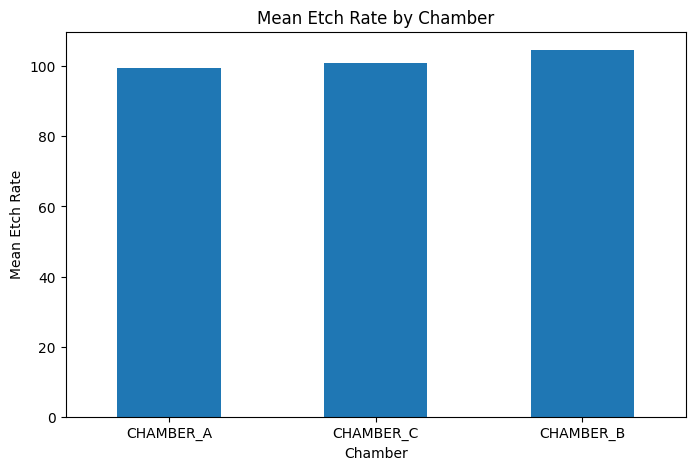

In [17]:
chamber_mean.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Mean Etch Rate by Chamber')
plt.xlabel('Chamber')
plt.ylabel('Mean Etch Rate')
plt.xticks(rotation=0)
plt.show()